In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
guybrush = cv2.imread('images/guybrush.jpg', 0)

guybrush_dft = cv2.dft(guybrush.astype(np.float32), flags = cv2.DFT_COMPLEX_OUTPUT)
guybrush_dft = np.fft.fftshift(guybrush_dft)
guybrush_dft.shape

(236, 236, 2)

log and scaling just for better visualization

In [3]:
guybrush_magnitude_spectrum = np.log(cv2.magnitude(guybrush_dft[:, :, 0], guybrush_dft[:, :, 1]))
guybrush_magnitude_spectrum = guybrush_magnitude_spectrum / (guybrush_magnitude_spectrum.max() - guybrush_magnitude_spectrum.min()) * 255
guybrush_magnitude_spectrum.shape

(236, 236)

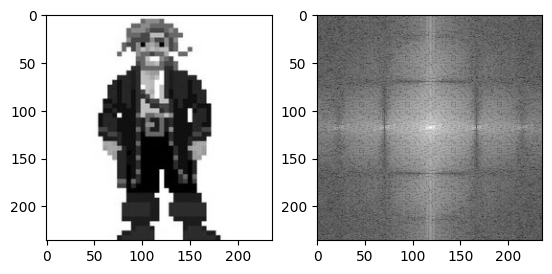

In [4]:
plt.subplot(121)
plt.imshow(guybrush, cmap='gray', vmin=0, vmax=255)
plt.subplot(122)
plt.imshow(guybrush_magnitude_spectrum, cmap='gray', vmin=0, vmax=255)

create a low-pass filter mask, center square is 1, remaining all zeros

In [5]:
rows, cols = guybrush.shape
crow, ccol = rows // 2, cols // 2

mask = np.zeros((rows, cols, 2), np.uint8)
mask[crow-30:crow+30, ccol-30:ccol+30] = 1

apply mask

In [6]:
guybrush_dft_masked = guybrush_dft * mask

inverse DFT

In [7]:
guybrush_dft_masked = np.fft.ifftshift(guybrush_dft_masked)
guybrush_back = cv2.idft(guybrush_dft_masked)

In [8]:
guybrush_back = cv2.magnitude(guybrush_back[:, :, 0], guybrush_back[:, :, 1])

guybrush_back = guybrush_back / guybrush_back.max() * 255
guybrush_back = guybrush_back.astype(np.uint8)

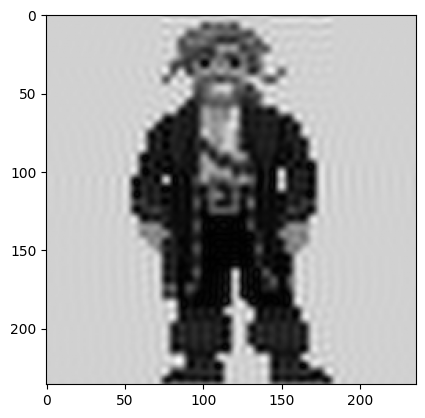

In [9]:
plt.imshow(guybrush_back, cmap='gray', vmin=0, vmax=255)